In [1]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import sys
sys.path.append('../')
import UTILS.utils as utils
import numpy as np
from tqdm.auto import tqdm
import pandas as pd

from umap import UMAP
from hdbscan import HDBSCAN
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import os
from sklearn.metrics import silhouette_samples, silhouette_score

## TOPIC MODELLING WITH BERTOPIC

In [3]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

In [4]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def test_hyperparameters(df, num_tokens, ngram_range, min_topic_size, n_neighbors, n_components):

    docs = df
    vectorizer_model = CountVectorizer(ngram_range=ngram_range, stop_words="english")


    umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, metric='cosine', low_memory=False, random_state=100)
    hdbscan_model = HDBSCAN(min_cluster_size=min_topic_size, metric='euclidean', prediction_data=True)
    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        embedding_model=embedding_model,
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        language='english', calculate_probabilities=True,
        verbose=False)
    
      
    topics, probs = topic_model.fit_transform(docs)

    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    topics = topic_model.get_topics()

    topic_words = [
        [word for word, _ in topic_model.get_topic(topic) if word != ""] for topic in topics
    ]

    coherence_model = CoherenceModel(topics=topic_words, 
                                texts=tokens, 
                                corpus=corpus,
                                dictionary=dictionary, 
                                coherence='c_v')
    coherence = coherence_model.get_coherence()

    embeddings = topic_model.embedding_model.embed(docs)
    silhouette = silhouette_score(X=embeddings, labels=topic_model.topics_)

    number_topics = len(topic_model.get_topic_info())
    results = {"num_topics" : number_topics, "coherence" : coherence, "silhouette" : silhouette, "num_tokens" : num_tokens, "ngram_range" : ngram_range, 
               "min_topic_size" : min_topic_size, "n_neighbors" : n_neighbors, "n_components" : n_components}

    return results

In [5]:
# all parameters to test
num_tokens_range = range(2, 10, 1)
n_gram_ranges = [(1, 1), (1, 2)]
min_topic_sizes = [10, 13, 15, 18, 20]
n_neighbors_all = range(4, 20, 4)
n_components_all = range(2, 10, 4)

all_possibilities = []

for num_tokens in num_tokens_range:
    for n_gram in n_gram_ranges:
        for min_topic_size in min_topic_sizes:
            for n_neighbors in n_neighbors_all:
                for n_components in n_components_all:
                    parameters = {
                        "num_tokens" : num_tokens,
                        "n_gram_range" : n_gram,
                        "min_topic_size" : min_topic_size,
                        "n_neighbors" : n_neighbors,
                        "n_components" : n_components
                    }
                    all_possibilities.append(parameters)

In [6]:
def test_all_hyperparameters(df):
    hyperparam_results = []
    for parameters in tqdm(all_possibilities):
        num_tokens = parameters["num_tokens"]
        n_gram_range = parameters["n_gram_range"]
        min_topic_size = parameters["min_topic_size"]
        n_neighbors = parameters["n_neighbors"]
        n_components = parameters["n_components"]

        results = test_hyperparameters(df, num_tokens, n_gram_range, min_topic_size, n_neighbors, n_components)
        hyperparam_results.append(results)
    return hyperparam_results

### SENTENCES

In [2]:
all_sentences = pd.read_csv(utils.ALL_SENTENCES_DF)
df = pd.DataFrame(all_sentences, columns=["text"])
train_data = [s.lower() for s in df["text"].to_list()]

In [ ]:
hyperparameters = test_all_hyperparameters(train_data)

In [25]:
hyperparameters_df = pd.DataFrame.from_dict(hyperparameters)
hyperparameters_df.to_csv("../../Data/HYPERPARAMS/BERTOPIC_sentences.csv", index=False)

In [26]:
def enough_topics(x):
    return x >= 10 and x <= 30

filtered_df = hyperparameters_df[hyperparameters_df["num_topics"].apply(lambda x : enough_topics(x))]
maxidx = filtered_df[["coherence"]].idxmax()
hyperparameters_df.iloc[maxidx]

,num_topics,coherence,silhouette,num_tokens,ngram_range,min_topic_size,n_neighbors,n_components
545,21,0.502682,-0.021937,8,"(1, 2)",18,4,6


In [29]:
import pandas as pd

df = pd.read_csv(utils.ALL_SENTENCES_DF)
docs = df["text"].to_list()
vectorizer_model = CountVectorizer(ngram_range=(1,2), stop_words="english")


umap_model = UMAP(n_neighbors=4, n_components=6, metric='cosine', low_memory=False, random_state=100)
hdbscan_model = HDBSCAN(min_cluster_size=18, metric='euclidean', prediction_data=True)
topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        embedding_model=embedding_model,
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        language='english', calculate_probabilities=True,
        verbose=False)
     
topics, probs = topic_model.fit_transform(docs)
freq = topic_model.get_topic_info()

In [31]:
for l in freq["Representation"]:
    print(l)

['street', 'city', 'left', 'great', 'water', 'wall', 'buildings', 'miles', 'legation', 'small']
['chinese', 'china', 'women', 'prince', 'rank', 'girls', 'foreign', 'world', 'feet', 'years']
['wall', 'city', 'gate', 'allies', 'feet', 'left', 'right', 'native', 'native city', 'distance']
['shanghai', 'chinese', 'river', 'european', 'miles', 'shall', 'city', 'china', 'street', 'hongkong']
['camera', 'stereoscope', 'picture', 'time', 'chair', 'parks', 'dr parks', 'stereoscopic', 'scarcely', 'photograph']
['tea', 'rice', 'mountain', 'paddy', 'fields', 'china', 'small', 'called', 'patches', 'cups']
['boats', 'river', 'boat', 'shore', 'line', 'harbor', 'long', 'cargoes', 'tow line', 'tow']
['map', 'red', 'red lines', 'lines', 'number', 'branch', 'connected number', 'lines connected', 'connected', 'field vision']
['boxer', 'boxers', 'sees', 'native', 'uprising', 'great', 'city', 'coolie', 'robbery', 'ravages']
['instruments', 'dragon', 'bronze', 'lions', 'chinese', 'ring', 'years', 'astronomic

### PARAGRAPHS

In [16]:
all_sentences = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")
df = pd.DataFrame(all_sentences, columns=["text"])
train_data = [s.lower() for s in df["text"].to_list()]

In [17]:
hyperparameters = test_all_hyperparameters(train_data)

  0%|          | 0/640 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [18]:
hyperparameters_df = pd.DataFrame.from_dict(hyperparameters)
hyperparameters_df.to_csv("../../Data/HYPERPARAMS/BERTOPIC_paragraphs.csv", index=False)

In [19]:
def enough_topics(x):
    return x >= 10 and x <= 30

filtered_df = hyperparameters_df[hyperparameters_df["num_topics"].apply(lambda x : enough_topics(x))]
maxidx = filtered_df[["coherence"]].idxmax()
hyperparameters_df.iloc[maxidx]

,num_topics,coherence,silhouette,num_tokens,ngram_range,min_topic_size,n_neighbors,n_components
42,10,0.619749,-0.003647,2,"(1, 2)",10,8,2


In [20]:
import pandas as pd

df = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")
docs = df["text"].to_list()
vectorizer_model = CountVectorizer(ngram_range=(1,2), stop_words="english")


umap_model = UMAP(n_neighbors=8, n_components=2, metric='cosine', low_memory=False, random_state=100)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', prediction_data=True)
topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        embedding_model=embedding_model,
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        language='english', calculate_probabilities=True,
        verbose=False)
     
topics, probs = topic_model.fit_transform(docs)
freq = topic_model.get_topic_info()

In [21]:
for l in freq["Representation"]:
    print(l)

['city', 'street', 'left', 'chinese', 'great', 'near', 'little', 'right', 'china', 'native']
['river', 'chinese', 'shanghai', 'miles', 'china', 'city', 'tea', 'european', 'hongkong', 'street']
['city', 'wall', 'map', 'lines', 'red lines', 'north', 'red', 'gate', 'number', 'hill']
['buddha', 'temple', 'hall', 'statues', 'called', 'time', 'palace', 'buildings', 'court', 'chinese']
['wall', 'gate', 'legation', 'left', 'city', 'chinese', 'legations', 'distance', 'guns', 'river']
['women', 'girls', 'chinese', 'china', 'feet', 'woman', 'work', 'little', 'dress', 'chinese women']
['mandarin', 'coolies', 'boy', 'reached', 'night', 'time', 'chair', 'tea', 'room', 'miles']
['river', 'boats', 'bridge', 'boat', 'fish', 'place', 'water', 'small', 'canal', 'crops']
['prince', 'li', 'foreign', 'board', 'yamên', 'prince ching', 'ching', 'court', 'affairs', 'chinese']
['tien tsin', 'tsin', 'tien', 'city', 'troops', 'arsenal', 'force', 'taku', 'war', 'day']


In [1]:
l = [['city', 'street', 'left', 'chinese', 'great', 'near', 'little', 'right', 'china', 'native'],
['river', 'chinese', 'shanghai', 'miles', 'china', 'city', 'tea', 'european', 'hongkong', 'street'],
['city', 'wall', 'map', 'lines', 'red lines', 'north', 'red', 'gate', 'number', 'hill'],
['buddha', 'temple', 'hall', 'statues', 'called', 'time', 'palace', 'buildings', 'court', 'chinese'],
['wall', 'gate', 'legation', 'left', 'city', 'chinese', 'legations', 'distance', 'guns', 'river'],
['women', 'girls', 'chinese', 'china', 'feet', 'woman', 'work', 'little', 'dress', 'chinese women'],
['mandarin', 'coolies', 'boy', 'reached', 'night', 'time', 'chair', 'tea', 'room', 'miles'],
['river', 'boats', 'bridge', 'boat', 'fish', 'place', 'water', 'small', 'canal', 'crops'],
['prince', 'li', 'foreign', 'board', 'yamên', 'prince ching', 'ching', 'court', 'affairs', 'chinese'],
['tien tsin', 'tsin', 'tien', 'city', 'troops', 'arsenal', 'force', 'taku', 'war', 'day']]

In [2]:
for x in l:
    t = ",".join(x[:8])
    s = "\item" + "\\" + "v" + "space{-0.2cm}[" + t + "]"
    print(s)

\item\vspace{-0.2cm}[city,street,left,chinese,great,near,little,right]
\item\vspace{-0.2cm}[river,chinese,shanghai,miles,china,city,tea,european]
\item\vspace{-0.2cm}[city,wall,map,lines,red lines,north,red,gate]
\item\vspace{-0.2cm}[buddha,temple,hall,statues,called,time,palace,buildings]
\item\vspace{-0.2cm}[wall,gate,legation,left,city,chinese,legations,distance]
\item\vspace{-0.2cm}[women,girls,chinese,china,feet,woman,work,little]
\item\vspace{-0.2cm}[mandarin,coolies,boy,reached,night,time,chair,tea]
\item\vspace{-0.2cm}[river,boats,bridge,boat,fish,place,water,small]
\item\vspace{-0.2cm}[prince,li,foreign,board,yamên,prince ching,ching,court]
\item\vspace{-0.2cm}[tien tsin,tsin,tien,city,troops,arsenal,force,taku]


<>:3: SyntaxWarning: invalid escape sequence '\i'
<>:3: SyntaxWarning: invalid escape sequence '\i'
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_85692/4021555186.py:3: SyntaxWarning: invalid escape sequence '\i'
  s = "\item" + "\\" + "v" + "space{-0.2cm}[" + t + "]"


In [30]:
from collections import Counter

topic_counts_raw = Counter(topics)
plot_data = freq[['Topic', 'Count']].rename(columns={'Topic': 'Topic ID', 'Count': 'Number of Documents'})
plot_data["Topic ID"] = plot_data["Topic ID"].apply(lambda x : int(x) + 1)
plot_data_sorted = plot_data.sort_values(by='Number of Documents', ascending=False)
topic_order = plot_data_sorted['Topic ID'].tolist()


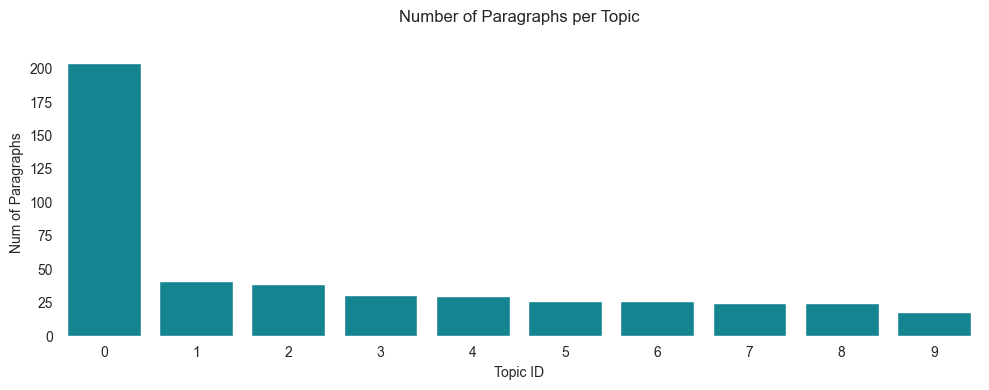

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Topic ID', y='Number of Documents', data=plot_data_sorted,
                 order=topic_order,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Paragraphs')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Number of Paragraphs per Topic', pad=20)

plt.tight_layout()
plt.show()